# 8. Verification and validation

Every model in the package is checked against an independent reference: a closed-form result, an
exact identity, an established library, or a statistical property that a correct implementation
must reproduce. This notebook shows the most important checks visually; the complete set runs as
part of the test suite (`uv run pytest -m validation`).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import montecarlo as mc
from investor_toolkit import risk
from investor_toolkit.plotting import plot_convergence

## Monte Carlo convergence

For a savings plan under GBM the mean and variance of final wealth are known exactly
(`montecarlo.gbm_wealth_moments`). The root-mean-square error of the simulated mean should fall as
$N^{-1/2}$ in the number of paths.

,exact,"simulated (50,000 paths)"
mean,51040.606,50992.829
standard deviation,24742.062,24804.684


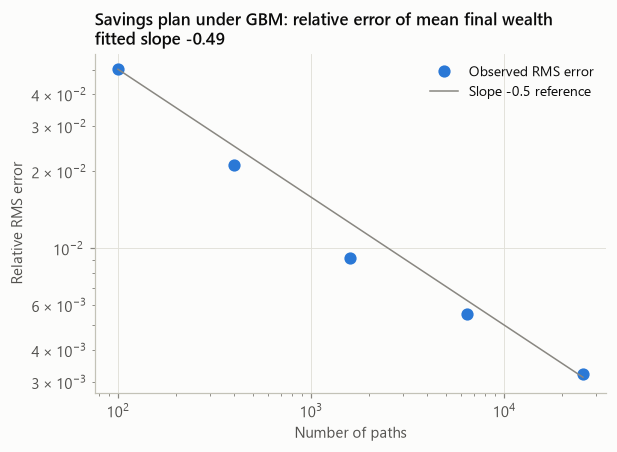

In [2]:
model = mc.GBM(expected_return=0.07, volatility=0.15)
plan = mc.SavingsPlan(monthly_contribution=100, contributions_indexed=False, accumulation_years=20)
exact_mean, exact_var = mc.gbm_wealth_moments(model, 100, 240)
sizes = np.array([100, 400, 1600, 6400, 25600])
rms = []
for n in sizes:
    errors = [
        mc.simulate(model, plan, int(n), seed=s).wealth[:, -1].mean() - exact_mean
        for s in range(30)
    ]
    rms.append(np.sqrt(np.mean(np.square(errors))))
ax = plot_convergence(
    sizes,
    np.array(rms) / exact_mean,
    title="Savings plan under GBM: relative error of mean final wealth",
)
ax.set_ylabel("Relative RMS error")
ax.figure.savefig(f"{FIGURES}/mc_convergence.png")

big = mc.simulate(model, plan, 50_000, seed=99).wealth[:, -1]
pd.DataFrame(
    {
        "exact": [exact_mean, np.sqrt(exact_var)],
        "simulated (50,000 paths)": [big.mean(), big.std()],
    },
    index=["mean", "standard deviation"],
)

## Variance reduction

Antithetic variates pair each random shock $z$ with $-z$. For a monotone quantity such as final
wealth this makes the paired estimates negatively correlated and reduces the variance of the mean.

In [3]:
plain = [
    mc.simulate(mc.GBM(0.07, 0.15), plan, 1000, seed=s).wealth[:, -1].mean() for s in range(100)
]
anti = [
    mc.simulate(mc.GBM(0.07, 0.15, antithetic=True), plan, 1000, seed=s).wealth[:, -1].mean()
    for s in range(100)
]
print(f"Variance reduction factor: {np.var(plain) / np.var(anti):.1f}")

Variance reduction factor: 3.9


## Drawdowns of Brownian motion and discrete monitoring

The expected maximum drawdown of driftless Brownian motion is $\sqrt{\pi/2}\,\sigma\sqrt{T}$.
A simulation observed at discrete times misses part of each peak and trough, so it underestimates
the drawdown by about $2\beta\sigma\sqrt{\Delta t}$ with $\beta = -\zeta(1/2)/\sqrt{2\pi} \approx 0.5826$
(Broadie, Glasserman and Kou, 1997). Both the convergence and the correction should be visible.

,raw,corrected,standard_error
steps,,,
50,1.096,1.260,0.008
200,1.165,1.248,0.008
800,1.218,1.259,0.008
3200,1.226,1.247,0.008


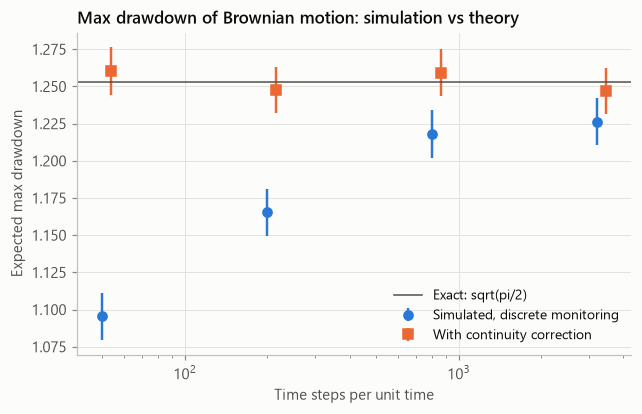

In [4]:
rng = np.random.default_rng(0)
exact = risk.expected_max_drawdown_brownian(1.0, 1.0)
rows = []
for steps in [50, 200, 800, 3200]:
    dt = 1.0 / steps
    paths = np.hstack(
        [np.zeros((4000, 1)), np.cumsum(rng.normal(0, np.sqrt(dt), (4000, steps)), axis=1)]
    )
    mdd = np.max(np.maximum.accumulate(paths, axis=1) - paths, axis=1)
    rows.append(
        {
            "steps": steps,
            "raw": mdd.mean(),
            "corrected": mdd.mean() + 2 * 0.5826 * np.sqrt(dt),
            "standard_error": mdd.std() / np.sqrt(4000),
        }
    )
table = pd.DataFrame(rows).set_index("steps")
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.errorbar(
    table.index,
    table["raw"],
    yerr=1.96 * table["standard_error"],
    fmt="o",
    color="#2a78d6",
    label="Simulated, discrete monitoring",
)
ax.errorbar(
    table.index * 1.08,
    table["corrected"],
    yerr=1.96 * table["standard_error"],
    fmt="s",
    color="#eb6834",
    label="With continuity correction",
)
ax.axhline(exact, color="#52514e", linewidth=1.0, label="Exact: sqrt(pi/2)")
ax.set_xscale("log")
ax.set_xlabel("Time steps per unit time")
ax.set_ylabel("Expected max drawdown")
ax.set_title("Max drawdown of Brownian motion: simulation vs theory")
ax.legend()
fig.savefig(f"{FIGURES}/drawdown_validation.png")
table

## Validation inventory

| Module | Reference | Check |
|---|---|---|
| `proxies` | Explicit cash-flow discounting | Par-bond price and modified duration |
| `proxies` | Investable ETFs | Correlation and tracking error of the long-history proxies |
| `returns` | Synthetic Student-t / AR(1) data | MLE recovers parameters; Hill recovers tail index; $VR(2) = 1 + \phi$; test size 5 % |
| `risk` | Closed-form normal and Student-t ES | Historical estimates converge to analytical values |
| `risk` | Brownian motion | Expected maximum drawdown with continuity correction |
| `risk` | Binomial exceptions | Kupiec test has nominal size |
| `diversification` | scikit-learn | Ledoit-Wolf shrinkage identical to 10 digits |
| `diversification` | Merton (1972) | Optimiser matches the analytical frontier |
| `diversification` | Truncated bivariate normal | Conditional correlation benchmark |
| `factors` | statsmodels | OLS, White and Newey-West standard errors |
| `factors` | Simulation | Newey-West intervals reach nominal coverage, classical ones do not |
| `backtest` | Exact accounting | Buy-and-hold, constant mix, costs, contributions, IRR |
| `backtest` | Simulation | Sharpe ratio standard error; expected maximum Sharpe of noise strategies |
| `resampling` | Politis and Romano (1994) | Bootstrap variance of the mean |
| `montecarlo` | Closed form | Lognormal terminal wealth; exact mean and variance with contributions |
| `montecarlo` | Theory | $N^{-1/2}$ convergence; antithetic variance reduction |
| `tax` | Hand calculation | Vorabpauschale, partial-year factor, FIFO; lifetime tax equals flat tax on total gain |